In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Team Success Probability — N-Survey Analysis (N ∈ {3, 4, 5})

This notebook implements the A/B/C/D metric for **any** number of surveys between 3 and 5. The number of surveys available at run-time is a single config knob (`N_SURVEYS`). The metric, the weights, and the roll-up logic all adapt automatically.

**Survey conventions (fixed).** S1 is always the pre-work baseline. S2…SN are during/after-work waves. Columns in S3, S4, S5 follow the dummy-data schema already established. If only 3 surveys are available, the notebook uses S1 + S2 + S3. If 4, S1 + S2 + S3 + S4. If 5, all of them.

## The metric — four components, generalised

For each person $i$ in team $t$, with $N$ surveys available ($N \in \{3,4,5\}$):

**(A) Level — recency-weighted mean standing across S2…S*N*.** For each $s \in \{2,\dots,N\}$, take the mean of per-person z-scores over that survey's success subset. Combine with recency weights $w^A_s$ that sum to 1 and increase with $s$:

$$A_i = \sum_{s=2}^{N} w^A_s \, \overline{z}^{(s)}_{i,\text{success}(s)}, \qquad \sum_{s=2}^{N} w^A_s = 1$$

**(B) Trajectory — recency-weighted sum of N−1 within-person segment deltas.** For each consecutive pair $(s, s{+}1)$ with $s \in \{1,\dots,N{-}1\}$, and each parameter $p$ in their overlap (team/solution items only — personal-state items excluded), compute $\Delta_{i,p,s\to s+1} = z^{(s+1)}_{i,p} - z^{(s)}_{i,p}$, average over the overlap, then combine segments with recency weights:

$$B_i = \sum_{s=1}^{N-1} w^B_{s\to s+1} \, \overline{\Delta}_{i,s\to s+1}, \qquad \sum w^B = 1$$

**(C) Baseline — S1 foundation.** Unchanged. $C_i$ = mean of per-person z-scores over the S1 team-characteristic subset.

**(D) Team consistency penalty — mean-of-means across all available surveys.** For each of the $N$ surveys, compute the per-parameter within-team std of z-scores, average across parameters. Then average across surveys, so each survey weighs equally.

## Default recency weights

Weights grow linearly with survey/segment index, normalised to sum to 1:

| N | $w^A$ on S2…S*N* | $w^B$ on segments S1→S2, …, S(N−1)→SN |
| --- | --- | --- |
| 3 | [0.33, 0.67] | [0.33, 0.67] |
| 4 | [0.17, 0.33, 0.50] | [0.17, 0.33, 0.50] |
| 5 | [0.10, 0.20, 0.30, 0.40] | [0.10, 0.20, 0.30, 0.40] |

At $N=5$ this matches the weights from the five-survey notebook (with the $w^A$ rebalanced so earliest-survey weight is 0.10, keeping shape consistent). Override via the config cell.

## From components to probability

$$S_i = 0.45\,A_i + 0.35\,B_i + 0.20\,C_i, \qquad \bar{S}_t = \tfrac{1}{|t|}\sum_{i \in t} S_i$$

$$P_{\text{success}}(t) = \sigma\!\left(k \cdot \left[\bar{S}_t - \lambda D_t - \overline{(\bar{S} - \lambda D)}\right]\right)$$

A team at the population mean with perfect internal agreement lands at $P = 0.5$; teams above/below move symmetrically. Ranking is invariant to the logistic's $k$ and the re-centring.

## 1. Imports and configuration

In [3]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

# === THE ONE KNOB: how many surveys are available this time? ===
# Must be 3, 4, or 5. S1 is always the pre-work baseline; S2..S_N are during/after.
N_SURVEYS = 4

assert 3 <= N_SURVEYS <= 5, 'N_SURVEYS must be 3, 4, or 5.'

# === File paths — only the first N_SURVEYS are actually used ===
ALL_SURVEY_PATHS = {
    1: Path('/content/drive/MyDrive/Real_data/real_data_1.csv'),
    2: Path('/content/drive/MyDrive/Real_data/real_data_2.csv'),
    3: Path('/content/drive/MyDrive/Real_data/real_data_3.csv'),
    4: Path('/content/drive/MyDrive/Real_data/real_data_4.csv'),
    5: Path('/content/drive/MyDrive/Real_data/real_data_5.csv'),
}
SURVEY_IDS = list(range(1, N_SURVEYS + 1))
SURVEY_PATHS = {s: ALL_SURVEY_PATHS[s] for s in SURVEY_IDS}

# === Individual-score weights (A, B, C) — unchanged from the two-survey metric ===
W_LEVEL      = 0.45
W_TRAJECTORY = 0.35
W_BASELINE   = 0.20
assert np.isclose(W_LEVEL + W_TRAJECTORY + W_BASELINE, 1.0)

# === Recency weight helper — linearly increasing, normalised to sum to 1 ===
def linear_recency_weights(n: int) -> list[float]:
    '''Return n positive weights that increase linearly and sum to 1.'''
    raw = np.arange(1, n + 1, dtype=float)   # 1, 2, ..., n
    return (raw / raw.sum()).tolist()

# w^A over S2..S_N  ->  N_SURVEYS - 1 weights
LEVEL_WEIGHTS = dict(zip(
    range(2, N_SURVEYS + 1),
    linear_recency_weights(N_SURVEYS - 1)
))

# w^B over segments (1->2, 2->3, ..., (N-1)->N)  ->  N_SURVEYS - 1 weights
SEGMENTS = [(s, s + 1) for s in range(1, N_SURVEYS)]
TRAJECTORY_WEIGHTS = dict(zip(SEGMENTS, linear_recency_weights(len(SEGMENTS))))

assert np.isclose(sum(LEVEL_WEIGHTS.values()), 1.0)
assert np.isclose(sum(TRAJECTORY_WEIGHTS.values()), 1.0)

# === Team-level settings ===
LAMBDA_CONSISTENCY = 0.50
LOGISTIC_K = 3.0

# === Parameter housekeeping ===
REVERSED_PARAMS = {'My level of cognitive load', 'Level of anxiety towards AI'}
NON_PARAM_COLS = {'Rater', 'team', 'person', 'Sex'}
# Personal-state items — excluded from the trajectory overlap so B reflects
# views of the team/solution, not how the person is feeling that day.
PERSONAL_STATE = {'Wellbeing', 'Team Access', 'Productivity', 'My level of cognitive load'}

print(f'Running with N_SURVEYS = {N_SURVEYS}: using surveys {SURVEY_IDS}')
print(f'Level weights (A):      {LEVEL_WEIGHTS}')
print(f'Trajectory weights (B): {TRAJECTORY_WEIGHTS}')

Running with N_SURVEYS = 4: using surveys [1, 2, 3, 4]
Level weights (A):      {2: 0.16666666666666666, 3: 0.3333333333333333, 4: 0.5}
Trajectory weights (B): {(1, 2): 0.16666666666666666, (2, 3): 0.3333333333333333, (3, 4): 0.5}


## 2. Load and clean the N available surveys

In [4]:
def clean_col(c: str) -> str:
    if not isinstance(c, str):
        return c
    c = re.sub(r'<[^>]+>', '', c).replace('&nbsp;', ' ').strip()
    c = re.sub(r'\s+', ' ', c)
    return c


def load_survey(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')])
    df.columns = [clean_col(c) for c in df.columns]
    return df


surveys = {s: load_survey(p) for s, p in SURVEY_PATHS.items()}

for s, df in surveys.items():
    print(f'Survey {s}: shape={df.shape}   teams={df["team"].nunique()}   raters={df["Rater"].nunique()}')

common_raters = set.intersection(*[set(df['Rater']) for df in surveys.values()])
print(f'\nRaters common to all {N_SURVEYS} surveys: {len(common_raters)}')
surveys[1].head(3)

Survey 1: shape=(89, 20)   teams=20   raters=89
Survey 2: shape=(74, 16)   teams=19   raters=74
Survey 3: shape=(67, 18)   teams=19   raters=67
Survey 4: shape=(47, 22)   teams=16   raters=47

Raters common to all 4 surveys: 21


,Rater,Wellbeing,Team Access,Productivity,Balance,Personal Style,Preferred Working Culture,Capacity of the team,Capability of the team,Collaboration within the team,Ability to challenge decisions and actions safely,My level of cognitive load,Level of anxiety towards AI,Level of knowledge of AI,Business usage of AI,Level of training and support received wrt AI,Opportunity to experiment and innovate with AI,Importance to you in your career,team,person
0,-1700002,63,48,31,36,35,48,42,46,34,68.0,34,40,30,33,52,34.0,72,17,2
1,-1700000,40,54,67,49,64,57,80,87,72,77.0,35,16,84,90,88,94.0,92,17,0
2,-2300004,44,48,52,56,48,48,42,46,50,54.0,58,40,44,48,52,56.0,60,23,4


## 3. Parameter inventory (data-driven)

The success subsets and trajectory overlaps are **derived from the data**, not hardcoded. That way, if S5 ships with a new parameter we didn't anticipate, the metric picks it up as long as it fits the semantic rules:

- **Success subset for survey $s$** = the numeric parameters in that survey that describe the team or the solution. Personal-state items are excluded. S1-only foundational items (AI knowledge, Balance, etc.) never enter the success subset even if they end up in S1's numeric columns.
- **S1 team subset** = the four team-characteristic items in S1 (Capacity, Capability, Collaboration, Challenge safely).
- **Trajectory overlap for segment $s{\to}s{+}1$** = parameters present in both surveys of the pair, minus personal-state items.

In [5]:
def numeric_params(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns
            if c not in NON_PARAM_COLS and pd.api.types.is_numeric_dtype(df[c])]

params = {s: numeric_params(df) for s, df in surveys.items()}

# === Success subset: team/solution items, pattern-matched so new parameters are picked up ===
# Anything that names the team or the solution qualifies. Personal-state and
# S1-specific foundational items are filtered out.
SUCCESS_PATTERNS = [
    r'of the team', r'within the team',            # Capacity/Capability/Priorities/Collaboration of/within the team
    r'challenge decisions',                         # Ability to challenge decisions and actions safely
    r'Leadership',
    r'our solution', r'are we being', r'are we with',  # solution / innovation / ambition items
    r'commercial application', r'beneficial',
    r'presented our solution',
]
SUCCESS_EXCLUDE = PERSONAL_STATE | {
    'HCD helped me to contribute more',
    'HCD helped our team understand how we were really working together',
    'The insights from the HCD influenced the way our team approached the challenge',
}

def build_success_subset(param_list: list[str]) -> list[str]:
    return [p for p in param_list
            if p not in SUCCESS_EXCLUDE
            and any(re.search(pat, p) for pat in SUCCESS_PATTERNS)]

# Survey-1 is special: its 'success' items are the 4 team-characteristic parameters.
S1_TEAM_PARAMS = [
    'Capacity of the team',
    'Capability of the team',
    'Collaboration within the team',
    'Ability to challenge decisions and actions safely',
]

# Success subsets only for S2..S_N (A is built over during/after-work surveys).
SUCCESS_SUBSETS = {s: build_success_subset(params[s]) for s in SURVEY_IDS if s >= 2}

# === Trajectory overlaps: consecutive pairs, team/solution items only ===
def team_overlap(s_from: int, s_to: int) -> list[str]:
    common = set(params[s_from]) & set(params[s_to])
    return sorted(common - PERSONAL_STATE)

TRAJECTORY_OVERLAPS = {seg: team_overlap(*seg) for seg in SEGMENTS}

# --- Report ---
print('Success subsets (component A):')
for s, subset in SUCCESS_SUBSETS.items():
    print(f'  S{s} ({len(subset)}): {subset}')

print('\nS1 team subset (component C):')
print(f'  ({len(S1_TEAM_PARAMS)}): {S1_TEAM_PARAMS}')

print('\nTrajectory overlaps (component B):')
for seg, ov in TRAJECTORY_OVERLAPS.items():
    print(f'  S{seg[0]}->S{seg[1]} ({len(ov)}): {ov}')

# Sanity checks
for p in S1_TEAM_PARAMS:
    assert p in params[1], f'S1 missing expected team param: {p}'
for s, subset in SUCCESS_SUBSETS.items():
    assert subset, f'Empty success subset for S{s}'
    for p in subset:
        assert p in params[s]

Success subsets (component A):
  S2 (9): ['Capacity of the team', 'Capability of the team', 'Priorities of the team', 'Collaboration within the team', 'Ability to challenge decisions and actions safely', 'Leadership of the team', 'How well our solution meets the objectives of the challenge', 'How innovative are we being in our use of technology', 'How ambitious are we with our solution']
  S3 (11): ['Capacity of the team', 'Capability of the team', 'Priorities of the team', 'Collaboration within the team', 'Ability to challenge decisions and actions safely', 'Leadership of the team', 'How well our solution meets the objectives of the challenge', 'How innovative are we being in our use of technology', 'How ambitious are we with our solution', 'What is the commercial application of our solution', 'How beneficial is our solution']
  S4 (12): ['Capacity of the team', 'Capability of the team', 'Priorities of the team', 'Collaboration within the team', 'Ability to challenge decisions and act

## 4. Per-person z-score normalisation (within each survey)

Subtract each person's own mean and divide by their own std, across their answers in a single survey. Reverse-coded items are negated first so that high = good everywhere. All downstream arithmetic operates on z-scores or differences of z-scores — **never on raw values averaged across surveys** — so the per-person scale invariance (the 'my 60 ≠ your 60' constraint) is preserved through every weighted sum that follows.

In [6]:
def person_zscore(df: pd.DataFrame, param_cols: list[str]) -> pd.DataFrame:
    X = df[param_cols].astype(float).copy()
    for c in REVERSED_PARAMS:
        if c in X.columns:
            X[c] = -X[c]
    mu = X.mean(axis=1)
    sd = X.std(axis=1, ddof=0).replace(0, np.nan)
    Z = X.sub(mu, axis=0).div(sd, axis=0).fillna(0)
    out = df[['Rater', 'team', 'person']].copy()
    return pd.concat([out, Z], axis=1)


z = {s: person_zscore(surveys[s], params[s]) for s in SURVEY_IDS}

for s in z:
    check = z[s][params[s]].mean(axis=1).abs().max()
    print(f'S{s}: max |row mean| after z-scoring = {check:.2e}  (should be ~0)')

S1: max |row mean| after z-scoring = 9.02e-17  (should be ~0)
S2: max |row mean| after z-scoring = 1.71e-16  (should be ~0)
S3: max |row mean| after z-scoring = 2.37e-16  (should be ~0)
S4: max |row mean| after z-scoring = 2.75e-16  (should be ~0)


## 5. Component A — Level (recency-weighted S2…S*N* standing)

In [7]:
def level_per_survey(z_df, subset):
    return z_df.set_index('Rater')[subset].mean(axis=1)

A_per_survey = {s: level_per_survey(z[s], SUCCESS_SUBSETS[s]) for s in LEVEL_WEIGHTS}

A_level = sum(LEVEL_WEIGHTS[s] * A_per_survey[s] for s in LEVEL_WEIGHTS).rename('A_level')

cols = {f'A_S{s}': A_per_survey[s] for s in LEVEL_WEIGHTS}
cols['A_level'] = A_level
pd.DataFrame(cols).head(10).round(3)

,A_S2,A_S3,A_S4,A_level
Rater,,,,
-3500008,NaN,0.343,0.369,NaN
-3500007,0.343,0.224,NaN,NaN
-3500004,0.311,NaN,NaN,NaN
-3500002,0.198,0.279,NaN,NaN
-2700008,NaN,NaN,0.389,NaN
-2700007,0.137,NaN,NaN,NaN
-2700006,0.233,NaN,NaN,NaN
-2700005,0.236,0.238,0.195,0.216
-2700003,0.214,0.129,0.351,0.254


## 6. Component B — Trajectory (chained within-person deltas)

$N-1$ segment deltas. Each delta is a difference of per-person z-scores, so rater style is removed twice over. Combined with recency weights that sum to 1.

In [8]:
def segment_delta(z_from, z_to, overlap):
    zf = z_from.set_index('Rater')[overlap]
    zt = z_to.set_index('Rater')[overlap]
    zf, zt = zf.align(zt, join='inner', axis=0)
    return (zt - zf).mean(axis=1)

B_per_segment = {
    seg: segment_delta(z[seg[0]], z[seg[1]], TRAJECTORY_OVERLAPS[seg])
    for seg in SEGMENTS
}

B_trajectory = sum(TRAJECTORY_WEIGHTS[seg] * B_per_segment[seg] for seg in SEGMENTS).rename('B_trajectory')

cols = {f'B_S{a}to{b}': B_per_segment[(a,b)] for (a,b) in SEGMENTS}
cols['B_trajectory'] = B_trajectory
pd.DataFrame(cols).head(10).round(3)

,B_S1to2,B_S2to3,B_S3to4,B_trajectory
Rater,,,,
-3500008,NaN,NaN,0.038,NaN
-3500007,-0.215,-0.114,NaN,NaN
-3500004,0.102,NaN,NaN,NaN
-3500002,-0.304,0.038,NaN,NaN
-2700005,0.416,-0.044,-0.024,0.043
-2700003,-0.017,-0.019,0.230,0.106
-2700002,0.005,-0.089,NaN,NaN
-2600009,NaN,NaN,-0.142,NaN
-2600008,NaN,NaN,0.078,NaN


## 7. Component C — Baseline (S1 foundation, unchanged)

In [9]:
C_baseline = z[1].set_index('Rater')[S1_TEAM_PARAMS].mean(axis=1).rename('C_baseline')
C_baseline.head(10).round(3)

,C_baseline
Rater,
-1700002,0.512
-1700000,0.546
-2300004,0.339
-2300003,0.425
-400002,0.346
-1700001,0.908
-400001,0.175
-400005,0.812
-1700004,0.500


## 8. Individual blended score

In [10]:
individuals = surveys[1].set_index('Rater')[['team', 'person']].copy()
individuals = individuals.join(A_level).join(B_trajectory).join(C_baseline)

individuals['individual_score'] = (
    W_LEVEL      * individuals['A_level']
    + W_TRAJECTORY * individuals['B_trajectory']
    + W_BASELINE   * individuals['C_baseline']
)

individuals.sort_values('individual_score', ascending=False).head(10).round(3)

,team,person,A_level,B_trajectory,C_baseline,individual_score
Rater,,,,,,
-200003,2,3,0.398,-0.047,0.913,0.345
-400004,4,4,0.313,0.063,0.576,0.278
-600004,6,4,0.384,0.174,0.160,0.266
-100003,1,3,0.292,-0.005,0.666,0.263
-600002,6,2,0.304,0.031,0.557,0.259
-200005,2,5,0.311,0.030,0.509,0.252
-2700003,27,3,0.254,0.106,0.441,0.240
-300000,3,0,0.274,-0.027,0.587,0.231
-2600005,26,5,0.366,-0.080,0.410,0.219


## 9. Team roll-up, disagreement penalty, probability

In [11]:
team_components = individuals.groupby('team')[
    ['A_level', 'B_trajectory', 'C_baseline', 'individual_score']
].mean().rename(columns={'individual_score': 'team_mean_score'})

def team_disagreement_one_survey(z_df, param_cols):
    return z_df.groupby('team')[param_cols].std(ddof=0).mean(axis=1)

disagreement_per_survey = pd.DataFrame({
    f'D_S{s}': team_disagreement_one_survey(z[s], params[s]) for s in SURVEY_IDS
})
team_components['D_disagreement'] = disagreement_per_survey.mean(axis=1)

team_components['penalised'] = (
    team_components['team_mean_score']
    - LAMBDA_CONSISTENCY * team_components['D_disagreement']
)

def logistic(x, k=LOGISTIC_K):
    return 1.0 / (1.0 + np.exp(-k * x))

team_components['P_success'] = logistic(
    team_components['penalised'] - team_components['penalised'].mean()
)

team_scores = team_components.sort_values('P_success', ascending=False).round(3)
team_scores

,A_level,B_trajectory,C_baseline,team_mean_score,D_disagreement,penalised,P_success
team,,,,,,,
1,0.292,-0.005,0.666,0.263,0.000,0.263,0.647
6,0.310,0.047,0.482,0.237,0.282,0.096,0.527
3,0.240,-0.034,0.465,0.212,0.246,0.089,0.521
17,0.265,-0.099,0.556,0.187,0.216,0.079,0.514
2,0.278,-0.027,0.681,0.250,0.356,0.072,0.508
19,0.257,-0.033,0.563,0.185,0.270,0.051,0.492
4,0.264,-0.019,0.394,0.216,0.339,0.047,0.490
27,0.235,0.074,0.435,0.179,0.290,0.034,0.480
11,0.196,-0.112,0.276,0.116,0.351,-0.059,0.411


In [ ]:
team_scores.to_csv('team_scores.csv')

## 10. Top and bottom teams

In [12]:
print(f'(Based on {N_SURVEYS} surveys)\n')
print('TOP 5 teams by P(success):')
print(team_scores[['team_mean_score', 'D_disagreement', 'P_success']].head(5))
print('\nBOTTOM 5 teams by P(success):')
print(team_scores[['team_mean_score', 'D_disagreement', 'P_success']].tail(5))

(Based on 4 surveys)

TOP 5 teams by P(success):
      team_mean_score  D_disagreement  P_success
team                                            
1               0.263           0.000      0.647
6               0.237           0.282      0.527
3               0.212           0.246      0.521
17              0.187           0.216      0.514
2               0.250           0.356      0.508

BOTTOM 5 teams by P(success):
      team_mean_score  D_disagreement  P_success
team                                            
22                NaN           0.000        NaN
23                NaN           0.344        NaN
24                NaN           0.196        NaN
34                NaN           0.000        NaN
35                NaN           0.226        NaN


## 11. Sensitivity checks

The sensitivity scenarios also adapt to N — uniform-weight comparisons work at any N.

In [13]:
def rank_under_weights(wL, wT, wB, level_w=None, traj_w=None,
                       lam=LAMBDA_CONSISTENCY, k=LOGISTIC_K):
    lw = level_w if level_w is not None else LEVEL_WEIGHTS
    tw = traj_w  if traj_w  is not None else TRAJECTORY_WEIGHTS
    A = sum(lw[s] * A_per_survey[s] for s in lw)
    B = sum(tw[seg] * B_per_segment[seg] for seg in tw)
    C = C_baseline
    ind = wL * A + wT * B + wB * C
    ind = pd.DataFrame({'team': individuals['team'], 'score': ind})
    team_mean = ind.groupby('team')['score'].mean()
    pen = team_mean - lam * team_components['D_disagreement']
    return logistic(pen - pen.mean(), k=k)

uniform_level_w = {s: 1/len(LEVEL_WEIGHTS) for s in LEVEL_WEIGHTS}
uniform_traj_w  = {seg: 1/len(TRAJECTORY_WEIGHTS) for seg in TRAJECTORY_WEIGHTS}

scenarios = {
    'default (.45/.35/.20)':          (0.45, 0.35, 0.20, None, None),
    'level-heavy (.60/.25/.15)':      (0.60, 0.25, 0.15, None, None),
    'trajectory-heavy (.25/.55/.20)': (0.25, 0.55, 0.20, None, None),
    'equal (1/3 each)':               (1/3, 1/3, 1/3, None, None),
    'A: uniform wave weights':        (0.45, 0.35, 0.20, uniform_level_w, None),
    'B: uniform segment weights':     (0.45, 0.35, 0.20, None, uniform_traj_w),
}

sens = pd.DataFrame({name: rank_under_weights(*args).round(3) for name, args in scenarios.items()})
sens = sens.sort_values('default (.45/.35/.20)', ascending=False)
sens

,default (.45/.35/.20),level-heavy (.60/.25/.15),trajectory-heavy (.25/.55/.20),equal (1/3 each),A: uniform wave weights,B: uniform segment weights
team,,,,,,
1.0,0.647,0.642,0.645,0.661,0.646,0.641
6.0,0.527,0.529,0.530,0.515,0.518,0.527
3.0,0.521,0.515,0.523,0.533,0.523,0.508
17.0,0.514,0.518,0.502,0.518,0.520,0.518
2.0,0.508,0.503,0.505,0.526,0.507,0.506
19.0,0.492,0.495,0.492,0.486,0.495,0.496
4.0,0.490,0.488,0.490,0.494,0.489,0.485
27.0,0.480,0.478,0.499,0.457,0.477,0.492
11.0,0.411,0.415,0.408,0.404,0.414,0.414


## 12. Rank stability across scenarios

In [14]:
from scipy.stats import spearmanr

default = sens['default (.45/.35/.20)']
stability = pd.Series({
    name: spearmanr(default, sens[name]).correlation
    for name in sens.columns
}, name='Spearman ρ vs default').round(3)
stability.sort_values(ascending=False).to_frame()

,Spearman ρ vs default
default (.45/.35/.20),NaN
level-heavy (.60/.25/.15),NaN
trajectory-heavy (.25/.55/.20),NaN
equal (1/3 each),NaN
A: uniform wave weights,NaN
B: uniform segment weights,NaN


## 13. Individual view — who's driving each team's signal

In [15]:
view = individuals.copy().round(3)
view = view.join(team_scores['P_success'], on='team')
view = view.sort_values(['P_success', 'team', 'individual_score'],
                        ascending=[False, True, False])
view[['team', 'person', 'A_level', 'B_trajectory', 'C_baseline',
      'individual_score', 'P_success']].head(25)

,team,person,A_level,B_trajectory,C_baseline,individual_score,P_success
Rater,,,,,,,
-100003,1,3,0.292,-0.005,0.666,0.263,0.647
-600004,6,4,0.384,0.174,0.160,0.266,0.527
-600002,6,2,0.304,0.031,0.557,0.259,0.527
-600003,6,3,0.241,-0.066,0.505,0.186,0.527
-600000,6,0,NaN,NaN,0.576,NaN,0.527
-600005,6,5,NaN,NaN,0.477,NaN,0.527
-600001,6,1,NaN,NaN,0.615,NaN,0.527
-300000,3,0,0.274,-0.027,0.587,0.231,0.521
-300002,3,2,0.207,-0.042,0.571,0.193,0.521


## 14. Inspect one team in detail

Per-survey A, per-segment B, per-survey D for the chosen team — all scale to whatever N was configured.

In [16]:
TEAM_TO_INSPECT = int(team_scores.index[0])

row = team_scores.loc[TEAM_TO_INSPECT]
print(f'=== Team {TEAM_TO_INSPECT}  (N={N_SURVEYS} surveys) ===')
print(f'P(success) = {row["P_success"]:.3f}')
print(f'Team mean score: {row["team_mean_score"]:+.3f}')
print(f'Disagreement D (mean of {N_SURVEYS} surveys): {row["D_disagreement"]:.3f}\n')

d_row = disagreement_per_survey.loc[TEAM_TO_INSPECT]
print('Per-survey disagreement:')
print(d_row.round(3).to_string(), '\n')

roster = individuals[individuals['team'] == TEAM_TO_INSPECT].sort_values('person')
detail = roster[['person', 'A_level', 'B_trajectory', 'C_baseline', 'individual_score']].copy()
for s in LEVEL_WEIGHTS:
    detail[f'A_S{s}'] = A_per_survey[s].reindex(roster.index).values
for seg in SEGMENTS:
    detail[f'B_S{seg[0]}->S{seg[1]}'] = B_per_segment[seg].reindex(roster.index).values

print('Member breakdown:')
detail.round(3)

=== Team 1  (N=4 surveys) ===
P(success) = 0.647
Team mean score: +0.263
Disagreement D (mean of 4 surveys): 0.000

Per-survey disagreement:
D_S1    0.0
D_S2    0.0
D_S3    0.0
D_S4    0.0 

Member breakdown:


,person,A_level,B_trajectory,C_baseline,individual_score,A_S2,A_S3,A_S4,B_S1->S2,B_S2->S3,B_S3->S4
Rater,,,,,,,,,,,
-100003,3,0.292,-0.005,0.666,0.263,0.298,0.249,0.318,-0.261,0.015,0.066


## 15. Cross-N comparison (optional diagnostic)

How much does the ranking change if we analyse with fewer surveys than are available? This lets you see how "informative" each additional survey is for the final ranking. If the ranking at N=3 already agrees strongly with N=5, the last two surveys are confirming rather than revising.

This cell reruns the whole pipeline for each N ≤ N_SURVEYS and compares rankings. It's purely diagnostic; skip if you just want the single-N output.

In [17]:
def run_pipeline(n_surveys: int) -> pd.Series:
    '''Run the full pipeline for a given N and return team P_success.'''
    sids = list(range(1, n_surveys + 1))
    lw = dict(zip(range(2, n_surveys + 1), linear_recency_weights(n_surveys - 1)))
    segs = [(s, s + 1) for s in range(1, n_surveys)]
    tw = dict(zip(segs, linear_recency_weights(len(segs))))

    succ = {s: build_success_subset(params[s]) for s in sids if s >= 2}
    overlaps = {seg: sorted((set(params[seg[0]]) & set(params[seg[1]])) - PERSONAL_STATE)
                for seg in segs}

    Aps = {s: z[s].set_index('Rater')[succ[s]].mean(axis=1) for s in lw}
    A = sum(lw[s] * Aps[s] for s in lw)

    Bps = {seg: segment_delta(z[seg[0]], z[seg[1]], overlaps[seg]) for seg in segs}
    B = sum(tw[seg] * Bps[seg] for seg in segs)

    C = z[1].set_index('Rater')[S1_TEAM_PARAMS].mean(axis=1)

    ind_score = W_LEVEL * A + W_TRAJECTORY * B + W_BASELINE * C
    df = pd.DataFrame({'team': individuals['team'], 'score': ind_score})
    team_mean = df.groupby('team')['score'].mean()

    dis = pd.DataFrame({
        f's{s}': z[s].groupby('team')[params[s]].std(ddof=0).mean(axis=1) for s in sids
    }).mean(axis=1)

    pen = team_mean - LAMBDA_CONSISTENCY * dis
    return logistic(pen - pen.mean())


cross_n = pd.DataFrame({f'N={n}': run_pipeline(n).round(3) for n in range(3, N_SURVEYS + 1)})
cross_n = cross_n.sort_values(cross_n.columns[-1], ascending=False)

print(f'P(success) rankings at each N up to {N_SURVEYS}:\n')
print(cross_n)

print(f'\nSpearman ρ vs N={N_SURVEYS} ranking:')
ref = cross_n[f'N={N_SURVEYS}']
for col in cross_n.columns:
    rho = spearmanr(ref, cross_n[col]).correlation
    print(f'  {col}: ρ = {rho:.3f}')

P(success) rankings at each N up to 4:

        N=3    N=4
team              
1.0   0.630  0.647
6.0   0.514  0.527
3.0   0.502  0.521
17.0  0.544  0.514
2.0   0.506  0.508
19.0  0.511  0.492
4.0   0.443  0.490
27.0  0.475  0.480
11.0  0.423  0.411
26.0  0.413  0.409
5.0     NaN    NaN
12.0  0.538    NaN
13.0  0.561    NaN
14.0    NaN    NaN
16.0    NaN    NaN
18.0    NaN    NaN
22.0  0.441    NaN
23.0    NaN    NaN
24.0    NaN    NaN
25.0    NaN    NaN
34.0    NaN    NaN
35.0  0.498    NaN

Spearman ρ vs N=4 ranking:
  N=3: ρ = nan
  N=4: ρ = nan


## 16. (Optional) Export

In [ ]:
# team_scores.to_csv(f'team_success_N{N_SURVEYS}.csv')
# individuals.round(3).to_csv(f'individual_scores_N{N_SURVEYS}.csv')
# disagreement_per_survey.round(3).to_csv(f'disagreement_per_survey_N{N_SURVEYS}.csv')

## Summary of what became modular

1. **`N_SURVEYS` is the single switch.** Everything downstream — success subsets, trajectory overlaps, level weights, trajectory weights, disagreement pooling, the cross-N diagnostic — reads from the config cell and adapts.
2. **Recency weights scale to N.** `linear_recency_weights(n)` produces normalised weights that grow linearly with survey/segment index. At N=5 this gives the same shape we used before; at N=3 or N=4 the shape compresses sensibly.
3. **Success subsets are pattern-matched, not hardcoded.** If S4 or S5 ships with a new team/solution parameter we hadn't seen, it enters the subset automatically via the `SUCCESS_PATTERNS` list. Personal-state and HCD reflection items are explicitly excluded so A always measures "good team, good solution" and nothing else.
4. **The formula is now $N$-parameterised end-to-end:** A is a weighted average of $N-1$ per-survey levels, B is a weighted sum of $N-1$ within-person deltas, C is fixed at S1, D pools across $N$ surveys. At $N=5$ the output is identical to the previous notebook; at $N=3$ or $N=4$ the metric degrades gracefully to a shorter horizon without changing its structure.
5. **The cross-N diagnostic** (§15) shows you how much each additional survey moves the ranking — useful for deciding whether to wait for S5 to arrive before acting on the results.

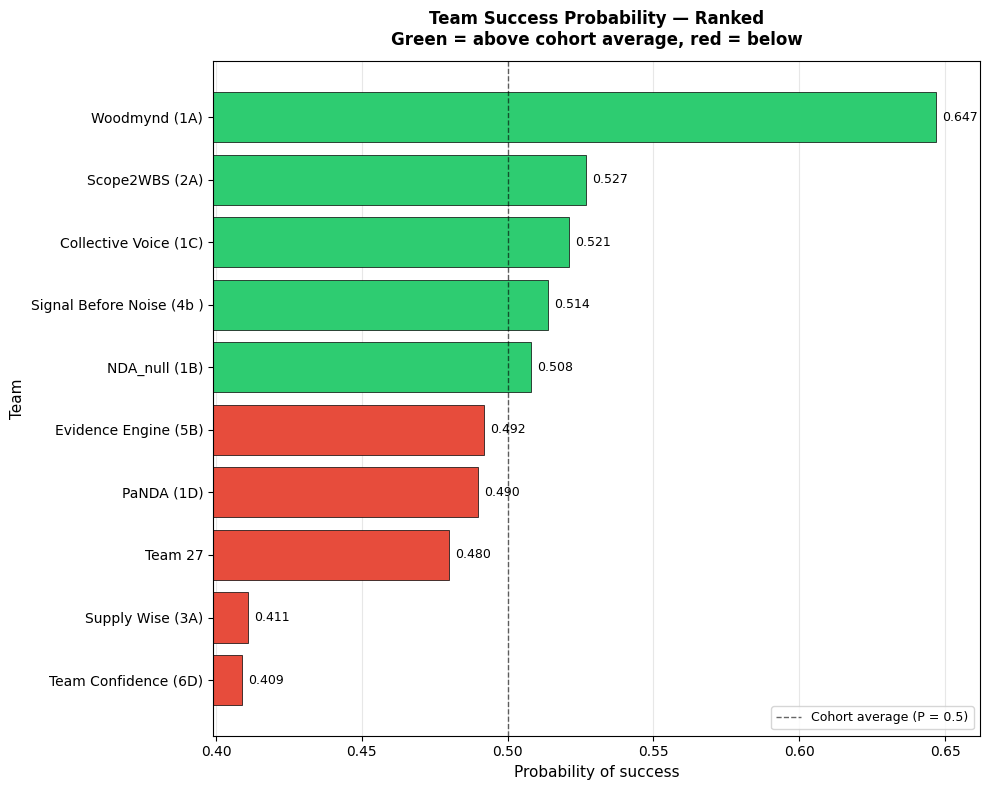

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the anon-to-team-name mapping
mapping_df = pd.read_excel(
    '/content/drive/MyDrive/Real_data/Anon link to Team name v01.xlsx',
    sheet_name='Hack27 Teams'
)[['Team Name', 'Team Room', 'Anon Team']].dropna(subset=['Anon Team'])

mapping_df['Anon Team'] = mapping_df['Anon Team'].astype(int)

# Build a lookup: anon id -> "Team Name (Team Room)"
label_lookup = {
    row['Anon Team']: f"{row['Team Name']} ({row['Team Room']})"
    for _, row in mapping_df.iterrows()
}

fig, ax = plt.subplots(figsize=(10, 8))

ranked = team_scores.sort_values('P_success', ascending=True)
colors = ['#2ecc71' if p >= 0.5 else '#e74c3c' for p in ranked['P_success']]

# Map each anon team id to the proper label; fall back to "Team {id}" if missing
labels = [label_lookup.get(t, f'Team {t}') for t in ranked.index]

bars = ax.barh(
    labels,
    ranked['P_success'],
    color=colors,
    edgecolor='black',
    linewidth=0.5,
)

ax.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.6,
           label='Cohort average (P = 0.5)')

for bar, value in zip(bars, ranked['P_success']):
    ax.text(value + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{value:.3f}', va='center', fontsize=9)

ax.set_xlabel('Probability of success', fontsize=11)
ax.set_ylabel('Team', fontsize=11)
ax.set_title('Team Success Probability — Ranked\n'
             'Green = above cohort average, red = below',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(ranked['P_success'].min() - 0.01,
            ranked['P_success'].max() + 0.015)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

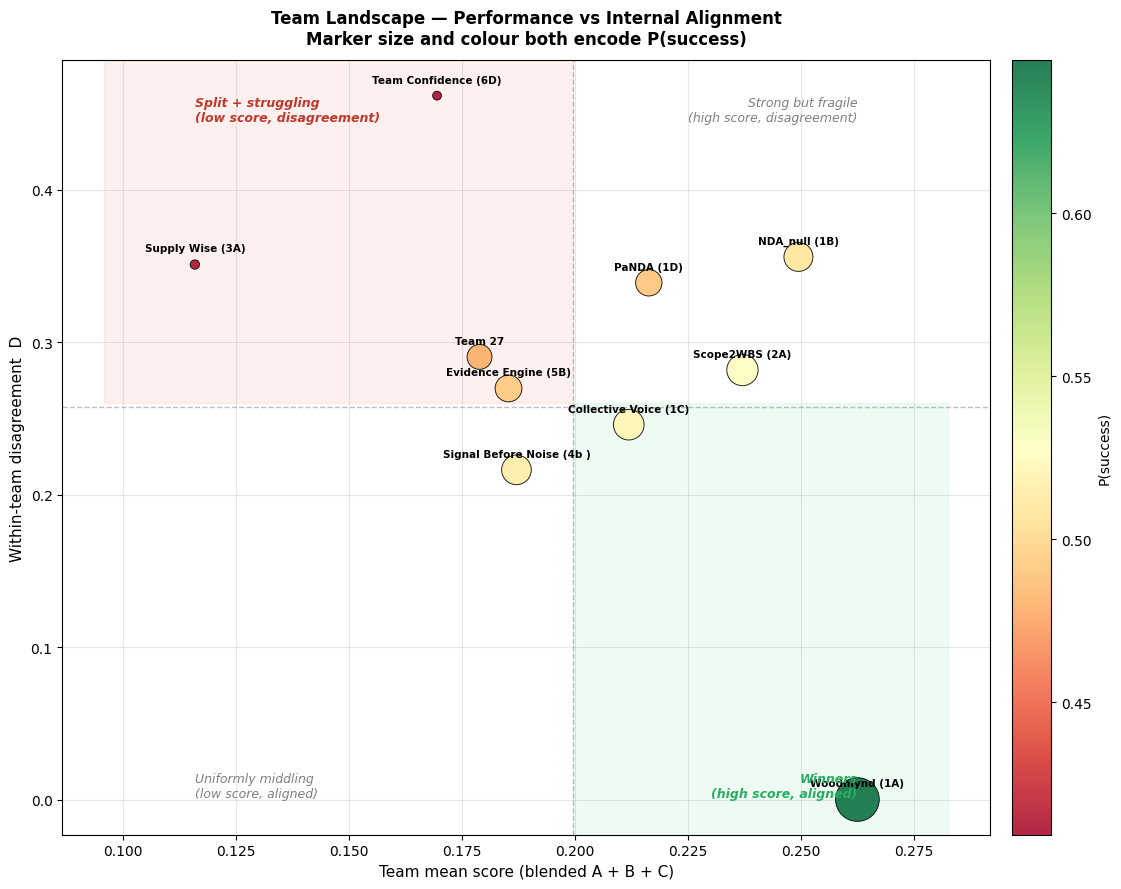

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the anon-to-team-name mapping
mapping_df = pd.read_excel(
    '/content/drive/MyDrive/Real_data/Anon link to Team name v01.xlsx',
    sheet_name='Hack27 Teams'
)[['Team Name', 'Team Room', 'Anon Team']].dropna(subset=['Anon Team'])

mapping_df['Anon Team'] = mapping_df['Anon Team'].astype(int)

label_lookup = {
    row['Anon Team']: f"{row['Team Name']} ({row['Team Room']})"
    for _, row in mapping_df.iterrows()
}

fig, ax = plt.subplots(figsize=(12, 9))

x = team_components['team_mean_score']
y = team_components['D_disagreement']
sizes = (team_components['P_success'] - team_components['P_success'].min() + 0.01) * 4000
colors = team_components['P_success']

# Median splits define the four quadrants
x_mid = x.median()
y_mid = y.median()

# Quadrant shading
ax.axvspan(x_mid, x.max() + 0.02, ymin=0, ymax=(y_mid - y.min() + 0.005) / (y.max() - y.min() + 0.01),
           color='#2ecc71', alpha=0.08)   # top-performers (high score, low disagreement)
ax.axvspan(x.min() - 0.02, x_mid, ymin=(y_mid - y.min() + 0.005) / (y.max() - y.min() + 0.01), ymax=1,
           color='#e74c3c', alpha=0.08)   # split + struggling (low score, high disagreement)

ax.axvline(x_mid, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(y_mid, color='gray', linestyle='--', linewidth=1, alpha=0.5)

scatter = ax.scatter(x, y, s=sizes, c=colors, cmap='RdYlGn',
                     edgecolor='black', linewidth=0.7, alpha=0.85)

# Annotate each bubble with "Team Name (Team Room)", offset slightly above the marker
for team_id, xi, yi, s in zip(team_components.index, x, y, sizes):
    label = label_lookup.get(team_id, f'Team {team_id}')
    # Offset vertically based on marker radius so text sits just above the bubble
    offset = (s ** 0.5) / 200 * (y.max() - y.min()) * 0.04
    ax.annotate(label, (xi, yi), xytext=(0, 8), textcoords='offset points',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# Quadrant labels in the corners
ax.text(x.max(), y.min(), 'Winners\n(high score, aligned)',
        ha='right', va='bottom', fontsize=9, style='italic',
        color='#27ae60', fontweight='bold')
ax.text(x.min(), y.max(), 'Split + struggling\n(low score, disagreement)',
        ha='left', va='top', fontsize=9, style='italic',
        color='#c0392b', fontweight='bold')
ax.text(x.max(), y.max(), 'Strong but fragile\n(high score, disagreement)',
        ha='right', va='top', fontsize=9, style='italic', color='gray')
ax.text(x.min(), y.min(), 'Uniformly middling\n(low score, aligned)',
        ha='left', va='bottom', fontsize=9, style='italic', color='gray')

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('P(success)', fontsize=10)

ax.set_xlabel('Team mean score (blended A + B + C)', fontsize=11)
ax.set_ylabel('Within-team disagreement  D', fontsize=11)
ax.set_title('Team Landscape — Performance vs Internal Alignment\n'
             'Marker size and colour both encode P(success)',
             fontsize=12, fontweight='bold', pad=12)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

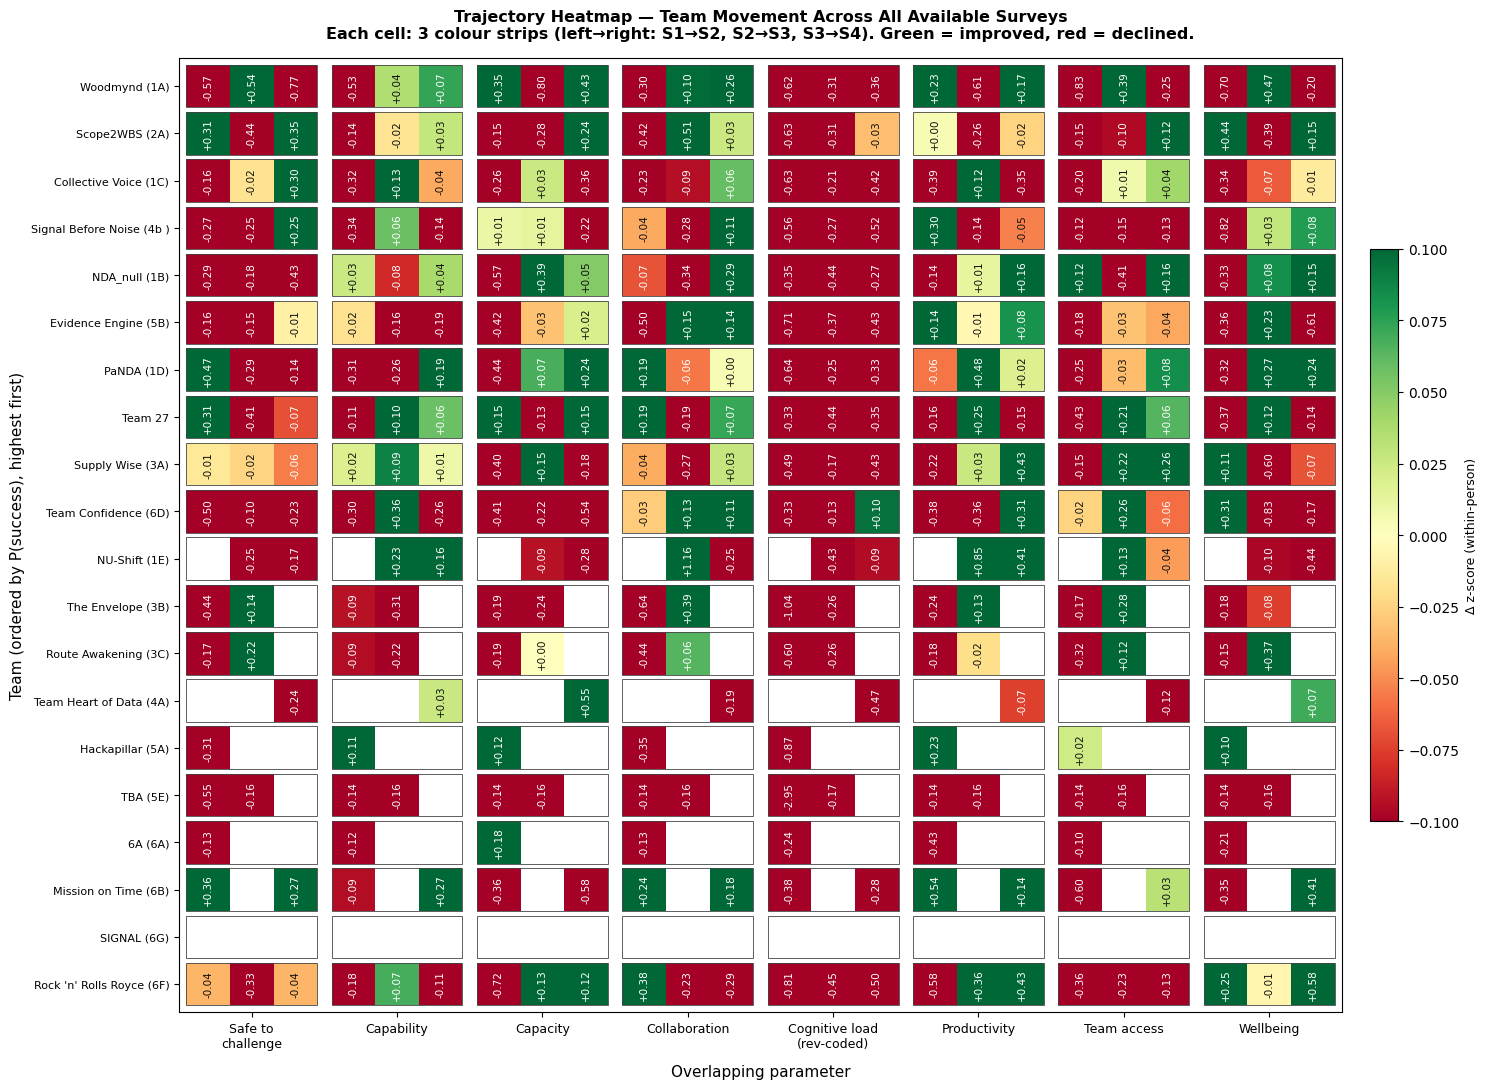

In [20]:
"""
Trajectory Heatmap — Team movement across all segments (N surveys).

Drop-in replacement for the original two-survey heatmap cell. Designed to
plug into the *flexible* notebook (or the five-survey notebook) so it uses
whichever segments and z-scores are already in memory.

Requires these names in scope (all created earlier in the notebook):
  - z                     : dict {survey_id -> z-scored DataFrame with 'team', 'Rater', ...}
  - SEGMENTS              : list of consecutive-pair tuples, e.g. [(1,2),(2,3),(3,4),(4,5)]
  - individuals           : DataFrame indexed by Rater with 'team' column
  - team_scores           : DataFrame indexed by team with 'P_success' column

Optional:
  - label_lookup          : dict {team_id -> "Team Name (Room)"}
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# --- Which parameters to show as columns ---
# The 8 items common to every segment's overlap, so all N-1 strips are defined per cell.
HEATMAP_PARAMS = [
    'Ability to challenge decisions and actions safely',
    'Capability of the team',
    'Capacity of the team',
    'Collaboration within the team',
    'My level of cognitive load',
    'Productivity',
    'Team Access',
    'Wellbeing',
]

SHORT_LABELS = {
    'Ability to challenge decisions and actions safely': 'Safe to\nchallenge',
    'Capability of the team': 'Capability',
    'Capacity of the team': 'Capacity',
    'Collaboration within the team': 'Collaboration',
    'My level of cognitive load': 'Cognitive load\n(rev-coded)',
    'Productivity': 'Productivity',
    'Team Access': 'Team access',
    'Wellbeing': 'Wellbeing',
}

# --- Compute team-mean Δz per (team, param, segment) ---
def _team_deltas_for_segment(z_from_df, z_to_df, pcols):
    a = z_from_df.set_index('Rater')[pcols]
    b = z_to_df.set_index('Rater')[pcols]
    a, b = a.align(b, join='inner', axis=0)
    delta = (b - a).copy()
    delta['team'] = z_from_df.set_index('Rater')['team']
    return delta.groupby('team')[pcols].mean()

seg_frames = {
    seg: _team_deltas_for_segment(z[seg[0]], z[seg[1]], HEATMAP_PARAMS)
    for seg in SEGMENTS
}

# --- Row order: strongest P(success) at the top ---
teams_ordered = team_scores.sort_values('P_success', ascending=False).index.tolist()
try:
    _lookup = label_lookup  # optional: defined if the mapping Excel was loaded
except NameError:
    _lookup = {t: f'Team {t}' for t in teams_ordered}
row_labels = [_lookup.get(t, f'Team {t}') for t in teams_ordered]

n_rows = len(teams_ordered)
n_cols = len(HEATMAP_PARAMS)
n_strips = len(SEGMENTS)

# --- Layout constants ---
# Each cell is CELL_W wide in x-axis units, STRIP_H tall in y-axis units.
# Within a cell, n_strips color blocks sit side-by-side with NO gap between them.
# Between cells (in x), leave INTER_GAP of empty space.
CELL_W     = 1.0
INTER_GAP  = 0.1                                   # blank space between adjacent cells
STRIP_W    = (CELL_W - INTER_GAP) / n_strips         # width of a single color block
STRIP_H    = 0.90                                    # fraction of a row's height filled by the cell
CLAMP_CBAR = 0.10                                    # colorbar saturation

cmap = plt.get_cmap('RdYlGn')
def _block_colour(v):
    t = np.clip((v + CLAMP_CBAR) / (2 * CLAMP_CBAR), 0, 1)
    return cmap(t)

# --- Figure sizing ---
fig_w = max(16, 1.8 * n_cols)
fig_h = max(11, 0.55 * n_rows)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

for i, team in enumerate(teams_ordered):
    y_centre = n_rows - 1 - i                # top row has highest y
    y_bottom = y_centre - STRIP_H / 2
    y_top    = y_centre + STRIP_H / 2

    for j, param in enumerate(HEATMAP_PARAMS):
        x_cell_centre = j
        cell_left  = x_cell_centre - (CELL_W - INTER_GAP) / 2

        for k, seg in enumerate(SEGMENTS):
            if team not in seg_frames[seg].index:
                continue
            v = seg_frames[seg].loc[team, param]
            if pd.isna(v):
                continue

            x_left = cell_left + k * STRIP_W
            # Full-height color block, strips joined (no gap within cell)
            rect = Rectangle((x_left, y_bottom), STRIP_W, STRIP_H,
                             facecolor=_block_colour(v),
                             edgecolor='none', zorder=2)
            ax.add_patch(rect)

            # Value text, rotated vertical, centered in the block
            intensity = min(1.0, abs(v) / CLAMP_CBAR)
            text_colour = 'white' if intensity > 0.55 else '#111'
            ax.text(x_left + STRIP_W / 2, y_centre, f'{v:+.2f}',
                    ha='center', va='center', fontsize=7.5,
                    rotation=90, color=text_colour, zorder=3)

        # Thin outline around the full cell (groups the N-1 strips visually)
        ax.add_patch(Rectangle((cell_left, y_bottom),
                               CELL_W - INTER_GAP, STRIP_H,
                               facecolor='none', edgecolor='#444',
                               linewidth=0.6, zorder=4))

ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(-0.6, n_rows - 0.4)
ax.set_aspect('auto')

ax.set_xticks(range(n_cols))
ax.set_xticklabels([SHORT_LABELS.get(p, p) for p in HEATMAP_PARAMS], fontsize=9)
ax.set_yticks([n_rows - 1 - i for i in range(n_rows)])
ax.set_yticklabels(row_labels, fontsize=8)

ax.set_xlabel('Overlapping parameter', fontsize=11, labelpad=10)
ax.set_ylabel('Team (ordered by P(success), highest first)', fontsize=11)

# Title describes the strip order dynamically so it stays correct if SEGMENTS changes
seg_order = ', '.join(f'S{a}→S{b}' for (a, b) in SEGMENTS)
ax.set_title('Trajectory Heatmap — Team Movement Across All Available Surveys\n'
             f'Each cell: {n_strips} colour strips (left→right: {seg_order}). '
             'Green = improved, red = declined.',
             fontsize=11.5, fontweight='bold', pad=14)

# Colorbar — same scale as the original two-survey chart
sm = ScalarMappable(norm=Normalize(vmin=-CLAMP_CBAR, vmax=CLAMP_CBAR), cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.6)
cbar.set_label('Δ z-score (within-person)', fontsize=9)

plt.tight_layout()
plt.show()

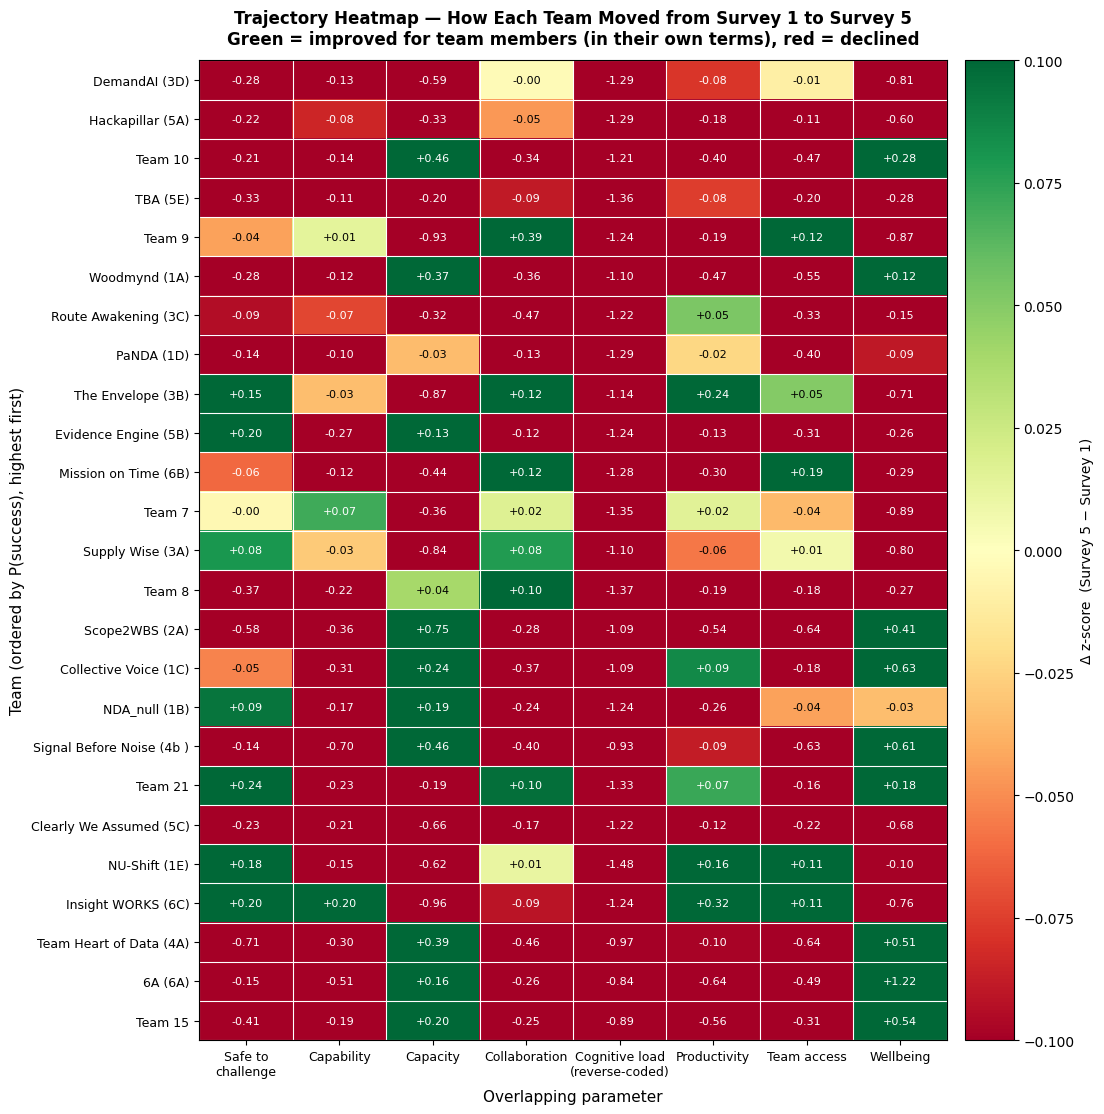

In [ ]:
"""
Trajectory Heatmap — compare ANY two surveys.

Same style as the original two-survey chart (continuous color fills, team-mean
delta-z on overlapping parameters), but you pick which surveys to compare.

Requires these names in scope (all created earlier in the notebook):
  - z            : dict {survey_id -> z-scored DataFrame with 'Rater','team',...}
  - individuals  : DataFrame indexed by Rater with 'team' column
  - team_scores  : DataFrame indexed by team with 'P_success' column

Optional:
  - label_lookup : dict {team_id -> "Team Name (Room)"}
  - PERSONAL_STATE : set of param names to exclude from the overlap (default applied below)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================
# === CHOOSE WHICH TWO SURVEYS TO COMPARE HERE ================
# =============================================================
SURVEY_FROM = 1      # earlier survey (e.g. 1, 2, 3, 4)
SURVEY_TO   = 5      # later survey  (e.g. 2, 3, 4, 5)
# =============================================================

# --- Validate the chosen pair ---
if SURVEY_FROM not in z or SURVEY_TO not in z:
    raise ValueError(f'Surveys {SURVEY_FROM} and/or {SURVEY_TO} are not in z. '
                     f'Available: {sorted(z.keys())}')
if SURVEY_FROM >= SURVEY_TO:
    raise ValueError(f'SURVEY_FROM ({SURVEY_FROM}) must be earlier than SURVEY_TO ({SURVEY_TO}).')

# --- Compute the overlap for the chosen pair ---
# Exclude purely personal-state items so the view reflects team/solution movement.
# (If PERSONAL_STATE is not defined in scope, use the standard set.)
try:
    _personal_state = PERSONAL_STATE
except NameError:
    _personal_state = {'Wellbeing', 'Team Access', 'Productivity', 'My level of cognitive load'}

NON_NUMERIC = {'Rater', 'team', 'person', 'Sex'}
def _numeric_cols(df):
    return [c for c in df.columns
            if c not in NON_NUMERIC and pd.api.types.is_numeric_dtype(df[c])]

from_cols = set(_numeric_cols(z[SURVEY_FROM]))
to_cols   = set(_numeric_cols(z[SURVEY_TO]))
# Note: include personal-state items here to match the style of the original chart,
# which showed Wellbeing / Team Access / Productivity / Cognitive load. Flip the
# `include_personal_state` flag below if you'd prefer team/solution items only.
include_personal_state = True
overlap_params = sorted(from_cols & to_cols) if include_personal_state \
                 else sorted((from_cols & to_cols) - _personal_state)

if not overlap_params:
    raise ValueError(f'No overlapping parameters between S{SURVEY_FROM} and S{SURVEY_TO}.')

# --- Team-mean Δz on each overlap parameter ---
z_from = z[SURVEY_FROM].set_index('Rater')[overlap_params]
z_to   = z[SURVEY_TO].set_index('Rater')[overlap_params]
z_from, z_to = z_from.align(z_to, join='inner', axis=0)

delta_by_person = (z_to - z_from)
delta_by_person['team'] = individuals['team']
delta_by_team = delta_by_person.groupby('team')[overlap_params].mean()

# --- Row order: strongest P(success) at the top ---
ordered_teams = team_scores.sort_values('P_success', ascending=False).index
heatmap_data = delta_by_team.loc[ordered_teams]

# --- Labels ---
SHORT_LABELS = {
    'Ability to challenge decisions and actions safely': 'Safe to\nchallenge',
    'Capability of the team': 'Capability',
    'Capacity of the team': 'Capacity',
    'Collaboration within the team': 'Collaboration',
    'Priorities of the team': 'Priorities',
    'Leadership of the team': 'Leadership',
    'How well our solution meets the objectives of the challenge': 'Solution vs\nobjective',
    'How innovative are we being in our use of technology': 'Innovation',
    'How ambitious are we with our solution': 'Ambition',
    'What is the commercial application of our solution': 'Commercial',
    'How beneficial is our solution': 'Beneficial',
    'How well have we presented our solution': 'Presentation',
    'My level of cognitive load': 'Cognitive load\n(reverse-coded)',
    'Productivity': 'Productivity',
    'Team Access': 'Team access',
    'Wellbeing': 'Wellbeing',
}
col_labels = [SHORT_LABELS.get(c, c) for c in heatmap_data.columns]

try:
    _lookup = label_lookup
except NameError:
    _lookup = {t: f'Team {t}' for t in ordered_teams}
row_labels = [_lookup.get(t, f'Team {t}') for t in ordered_teams]

# --- Plot ---
fig, ax = plt.subplots(figsize=(max(11, 1.4 * len(col_labels)), max(9, 0.45 * len(ordered_teams))))

# Symmetric colour range, clipped to ±0.10 like the original
vmax = 0.10
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto',
               vmin=-vmax, vmax=vmax)

# Cell annotations — black for mid-intensity, white for saturated cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        v = heatmap_data.values[i, j]
        ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                fontsize=8,
                color='black' if abs(v) < vmax * 0.6 else 'white')

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=0, fontsize=9)
ax.set_yticks(range(len(ordered_teams)))
ax.set_yticklabels(row_labels, fontsize=9)

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(f'Δ z-score  (Survey {SURVEY_TO} − Survey {SURVEY_FROM})', fontsize=10)

ax.set_xlabel('Overlapping parameter', fontsize=11, labelpad=8)
ax.set_ylabel('Team (ordered by P(success), highest first)', fontsize=11)
ax.set_title(f'Trajectory Heatmap — How Each Team Moved from Survey {SURVEY_FROM} to Survey {SURVEY_TO}\n'
             'Green = improved for team members (in their own terms), red = declined',
             fontsize=12, fontweight='bold', pad=12)

# Thin gridlines between cells
ax.set_xticks(np.arange(-0.5, len(col_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(ordered_teams), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=0.8)
ax.tick_params(which='minor', length=0)

plt.tight_layout()
plt.show()